In [1]:
from AutoencoderAPI.pytorchDataloader import pytorchDataloader
from AutoencoderAPI.recurentTriplet import recurentTriplet
from AutoencoderAPI.fileBatch import fileBatch
from AutoencoderAPI.transformer import transformer
from AutoencoderAPI.utils.plot import load_run_results, load_sweep_results
from AutoencoderAPI.sweep import sweep

KeyboardInterrupt: 

### Configuration

#### Triplet config

In [ ]:
run_config_Triplet = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",#Oxford",#NIST 1 (short)", #Oxford", #NIST (250)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250,      #4096#496#496#250#800
        },
'network' : {
        'activation_list'          : ['GELU', 'PReLU', 'GELU'],#GELU
        'layer_list'               : [200, 100, 1, 100, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'TripletMSE', #'TripletMarginLoss', #'sklearn_kmeans_silhouette_loss', #'MSELoss',
        'alpha'                    : 0.002,
        'epochs'                   : 10,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-6
        }
}

#### MSE config

In [ ]:
run_config_MSE = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",#Oxford",#NIST 1 (short)", #Oxford", #NIST (250)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250#4096#496#496#250#800
        },
'network' : {
        'activation_list'          : ['GELU', 'PReLU', 'GELU'],
        'layer_list'               : [200, 50, 1, 50, 200],
        'layer_number'             : 4,
        'layer_type'               : 'Linear'
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'sklearn_kmeans_silhouette_loss', #'TripletMarginLoss', #'sklearn_kmeans_silhouette_loss', #'MSELoss',
        'k-fold'                   : 2,
        'batch_number'             : 1,
        'epochs'                   : 4,
        'skip_elements'            : 1,
        'learning_rate'            : 1e-4
        }
}

#### Transformer config

In [ ]:
run_config_Transformer = {
'files' : {
        'dataset'                  : "Datasets/NIST (250)",#Oxford",#NIST 1 (short)", #Oxford", #NIST (250)",
        'path_save'                : 'Autoencoder Log/',
        'input_dimension'          : 250#496#496#250#800
        },
'network' : {
        'nhead'                    : 250,
        'dropout'                  : 0.1,
        'sequence_len'             : 1       # 
        },
'train' : {
        'optimizer'                : 'Adam',
        'criterion'                : 'MSELoss', #'TripletMarginLoss', #'sklearn_kmeans_silhouette_loss', #'MSELoss',
        'epochs'                   : 8,
        'learning_rate'            : 1e-6
        }
}

### Run

In [ ]:
func = recurentTriplet()
#func = fileBatch()
#func = transformer()
func.run(run_config_Triplet)

Epoch MSE:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/44800 [00:00<?, ?it/s]

  0%|          | 0/44800 [00:00<?, ?it/s]

  0%|          | 0/44800 [00:00<?, ?it/s]

  0%|          | 0/44800 [00:00<?, ?it/s]

Epoch Triplet:   0%|          | 0/10 [00:00<?, ?it/s]

### Sweep

In [ ]:
sweep_config = {
    'sweep_name'   : None,
    'search_param' : [('network','alpha'),('network','epochs')],
    'epochs'                   : [2,3,4,5,6,7,8],
    'learning_rate'            : [1e-3, 1e-4, 1e-5, 1e-6, 1e-7],
    'alpha'                    : [1e2, 1e1, 1e-0, 1e-1, 1e-2, 1e-3, 1e-4],
    'activation_possibilty'    : ['ReLU', 'Sigmoid', 'CELU', 'Softmax', 'Softmin', 'Hardshrink', 
                                    'LeakyReLU', 'ELU', 'LogSigmoid', 'PReLU', 'GELU', 'SiLU', 
                                    'Mish', 'Softplus', 'Softsign', 'Tanh'],
    'layer_size_possibility'   : [5,50,75,100,200]
}

In [ ]:
#exp = sweep()
#exp.grid_search("Transformer 1", run_config_Transformer, sweep_config)

### Load Run

Clusters:   0%|          | 0/40 [00:00<?, ?it/s]

Optimal number of clusters : 8
Optimal Silhouette score :  0.6336205


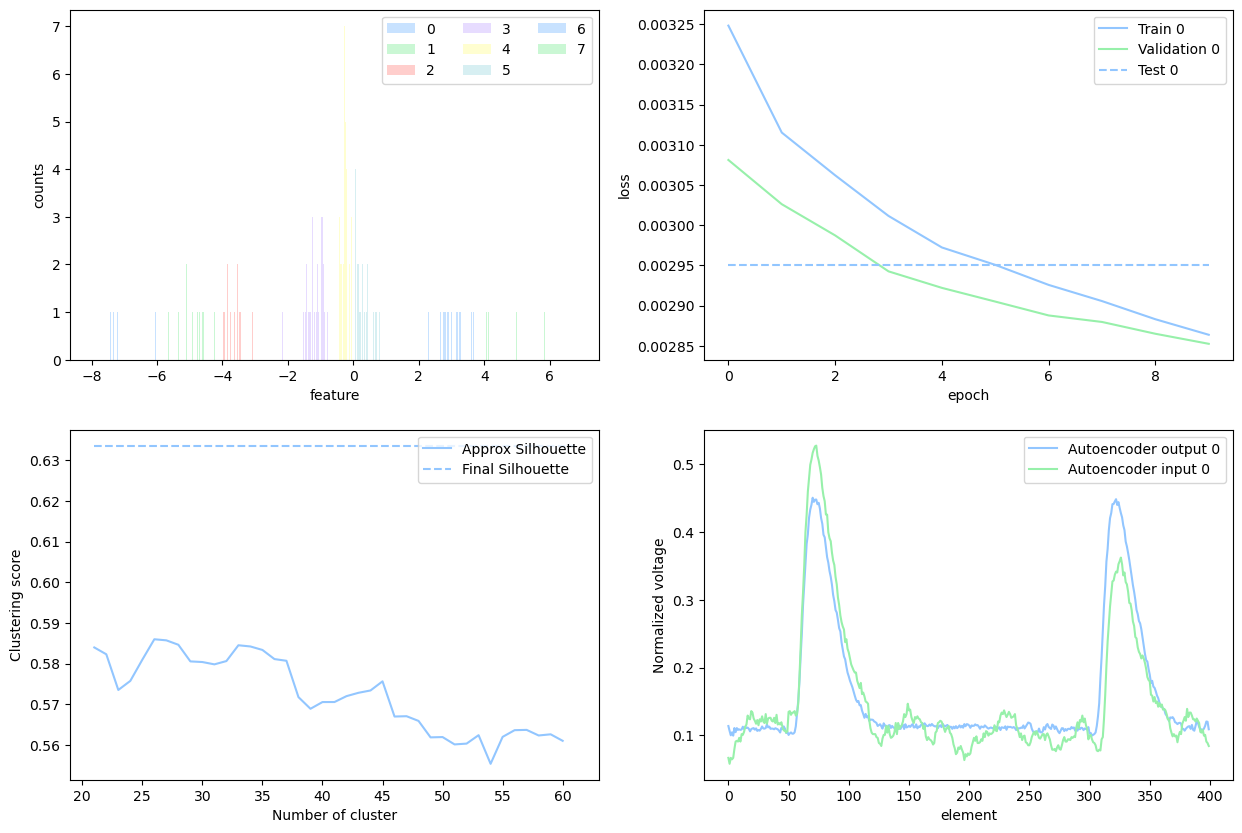

In [ ]:
load_run_results("run-2023-08-31-12-09", 20, 60)

### Load Sweep

In [ ]:
#load_sweep_results("TripletMSE 6", ["alpha", "epochs"])